In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

#load data

df = pd.read_csv('/content/drive/MyDrive/Pandas/Dataset/titanic.csv')


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.head(6)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.tail(7)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
884,0,3,male,25.0,0,0,7.050,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.125,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.450,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.750,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['fare'].nlargest(5)

,fare
258,512.3292
679,512.3292
737,512.3292
27,263.0000
88,263.0000


In [ ]:
# nlargest(5) is a Pandas method that returns the 5 largest values from a Series or DataFrame.
df.describe(include='O')

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [ ]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [ ]:
datamissing = df.isnull().sum()[df.isnull().sum() > 0]
datamissing

,0
age,177
embarked,2
deck,688
embark_town,2


In [ ]:
missing_percentage = (datamissing/len(df))*100
missing_percentage

,0
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467


In [ ]:
df.duplicated().sum()

np.int64(107)

In [ ]:
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df['embarked'].isnull().sum()

np.int64(2)

In [ ]:
df['embarked'].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [ ]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
df['embarked'].isnull().sum()

np.int64(0)

In [ ]:
df.groupby(['pclass', 'sex']).apply(lambda x: x.isnull().sum())

survived  pclass  sex  age  sibsp  parch  fare  embarked  \
pclass sex                                                                
1      female         0       0    0    9      0      0     0         0   
       male           0       0    0   21      0      0     0         0   
2      female         0       0    0    2      0      0     0         0   
       male           0       0    0    9      0      0     0         0   
3      female         0       0    0   42      0      0     0         0   
       male           0       0    0   94      0      0     0         0   

               class  who  adult_male  deck  embark_town  alive  alone  
pclass sex                                                              
1      female      0    0           0    13            2      0      0  
       male        0    0           0    28            0      0      0  
2      female      0    0           0    66            0      0      0  
       male        0    0           0   102            0      0      0  
3      female      0    0           0   138            0      0      0  
       male        0    0           0   341            0      0      0

In [ ]:
df['pclass'].value_counts()

,count
pclass,
3,491
1,216
2,184


In [ ]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


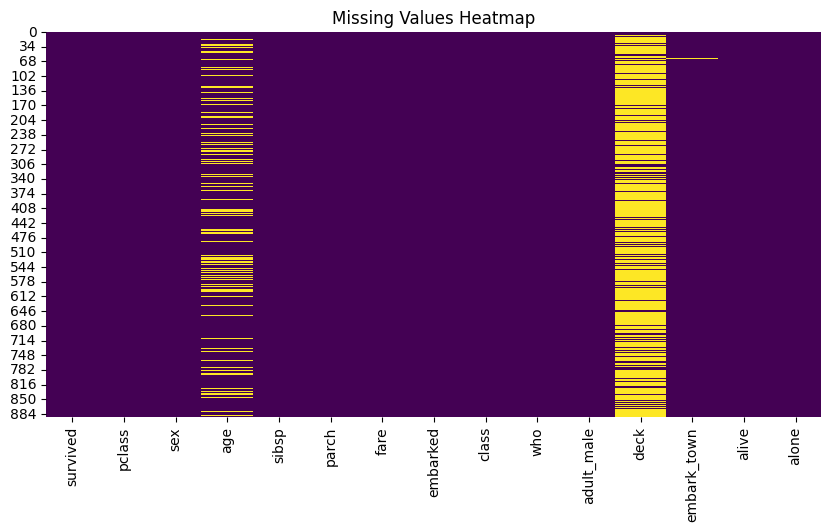

In [ ]:
# Visualize Missing Values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(107)

In [ ]:
# View Duplicate Rows
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Unique Values
df.nunique()

,0
survived,2
pclass,3
sex,2
age,88
sibsp,7
parch,7
fare,248
embarked,3
class,3
who,3


In [ ]:
# Check Unique Categories

df['sex'].unique()


array(['male', 'female'], dtype=object)

In [ ]:
df['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
df['pclass'].unique()

array([3, 1, 2])

In [ ]:
# Value Counts

df['survived'].value_counts()

,count
survived,
0,549
1,342


In [ ]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


In [ ]:
df['pclass'].value_counts()

,count
pclass,
3,491
1,216
2,184


In [ ]:
# Survival Percentage
df['survived'].value_counts(normalize=True)*100

,proportion
survived,
0,61.616162
1,38.383838


In [ ]:
# Correlation
df.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


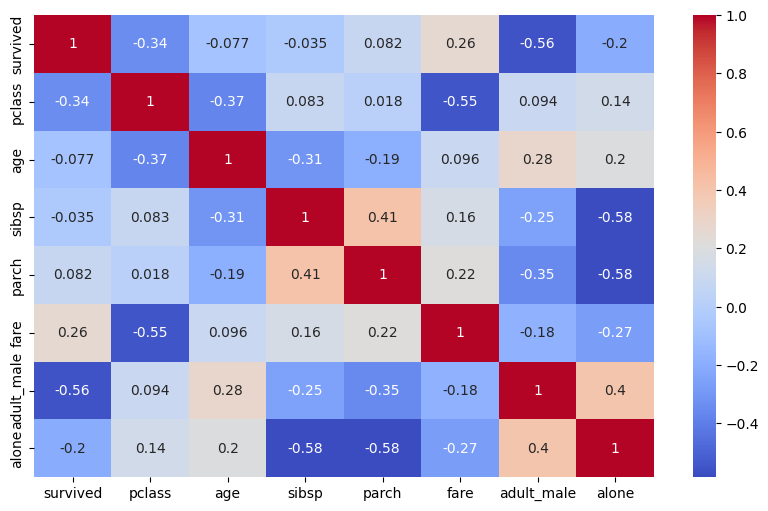

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

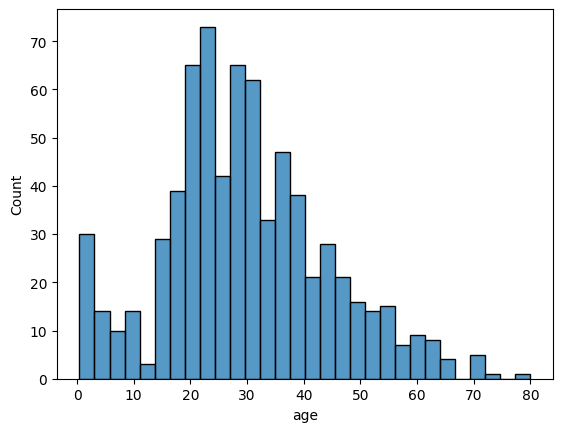

In [ ]:
# Distribution of Age
sns.histplot(df['age'], bins=30)
plt.show()

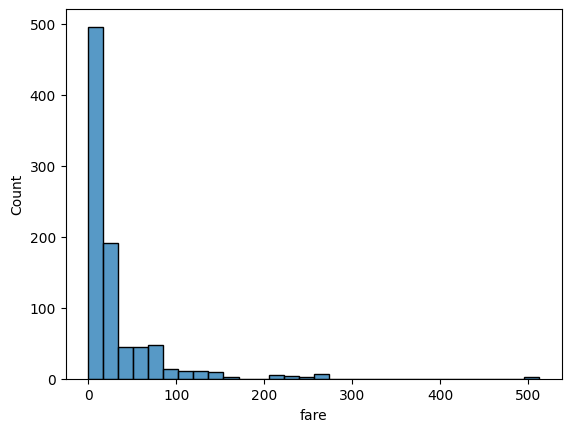

In [ ]:
# Distribution of Fare
sns.histplot(df['fare'], bins=30)
plt.show()

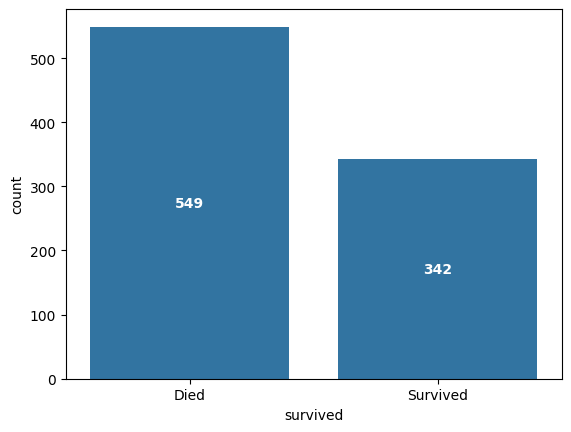

In [ ]:
ax = sns.countplot(x='survived', data=df)


# Replace 0 and 1 with custom names on the X-axis
ax.set_xticklabels(['Died', 'Survived'])

# Add the numbers inside the bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')

# Display the plot
plt.show()

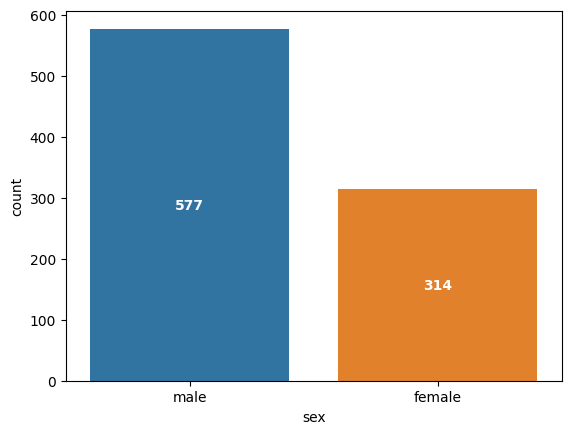

In [ ]:
# Gender Count
ax=sns.countplot(x='sex',hue='sex', data=df)

# Add the numbers inside the bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')

plt.show()

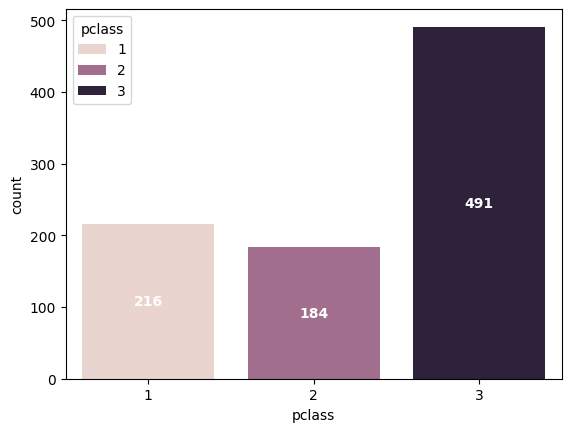

In [ ]:
# Passenger Class

ax=sns.countplot(x='pclass',hue='pclass', data=df)
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

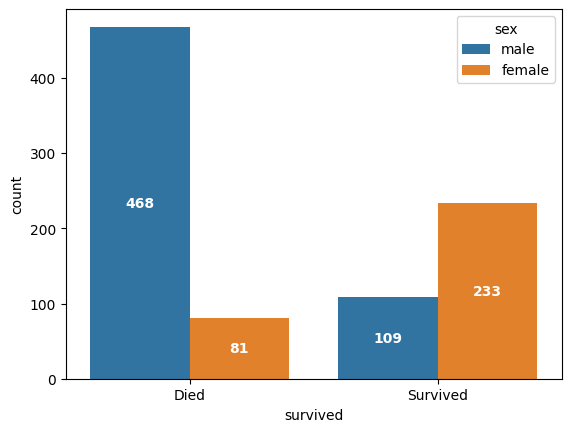

In [ ]:
# Survival by Gender

ax=sns.countplot(x='survived', hue='sex', data=df)
# Replace 0 and 1 with custom names on the X-axis
ax.set_xticklabels(['Died', 'Survived'])
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

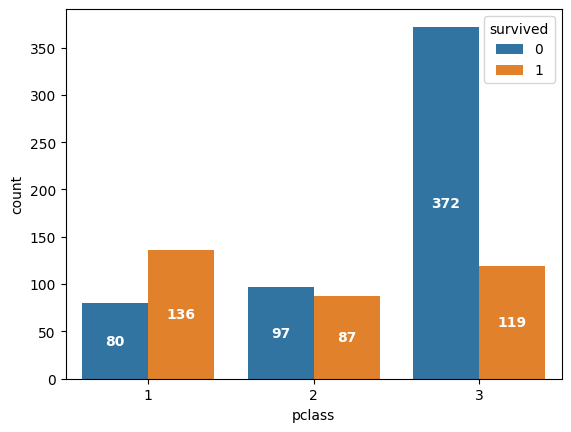

In [ ]:
# Survival by Passenger Class

ax=sns.countplot(x='pclass',hue='survived',data=df)
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

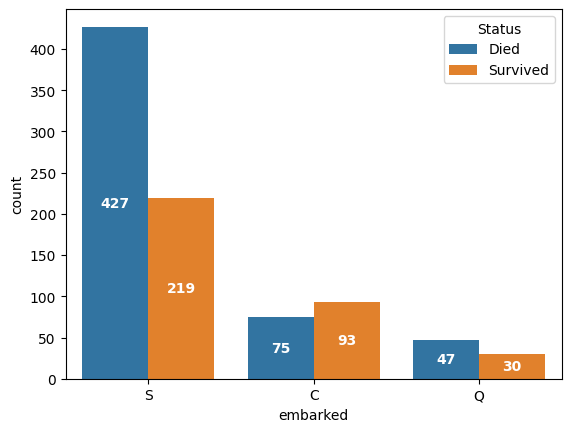

In [ ]:
# Survival by Embarked

ax=sns.countplot(x='embarked', hue='survived', data=df)
# Change the legend labels from 0 and 1 to Died and Survived
ax.legend(title='Status', labels=['Died', 'Survived'])
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

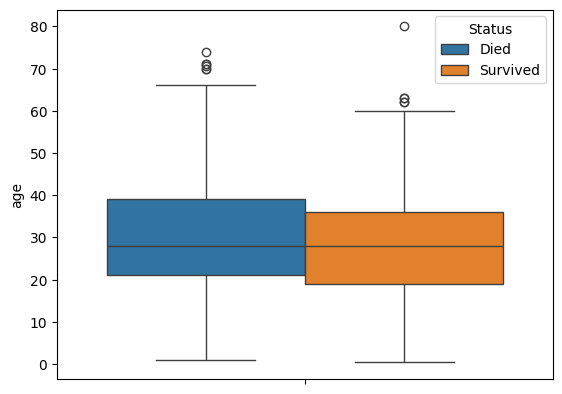

In [ ]:
# Age Boxplot
ax=sns.boxplot(y='age', hue='survived',data=df)
# Change the legend labels from 0 and 1 to Died and Survived
ax.legend(title='Status', labels=['Died', 'Survived'])

plt.show()

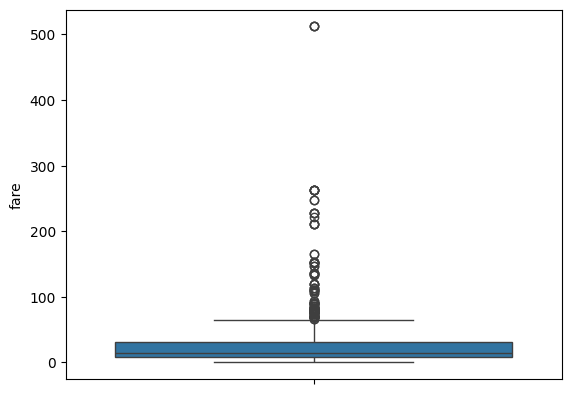

In [ ]:
# Fare Boxplot
sns.boxplot(y='fare', data=df)
plt.show()


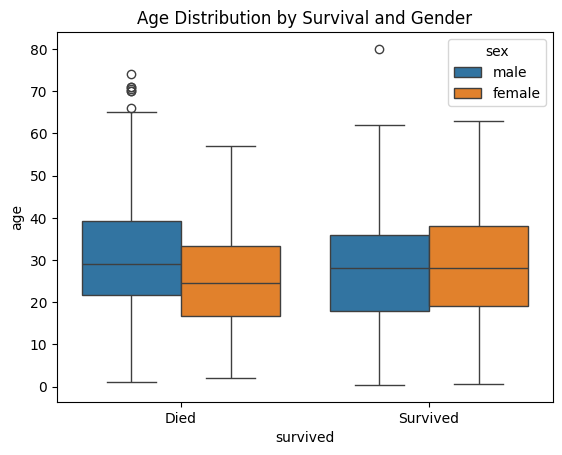

In [ ]:
# Age vs Survival

ax = sns.boxplot(x='survived', y='age', hue='sex', data=df)

# Fix the X-axis and Legend labels for human readability
ax.set_xticklabels(['Died', 'Survived'])
ax.set_title('Age Distribution by Survival and Gender')

plt.show()

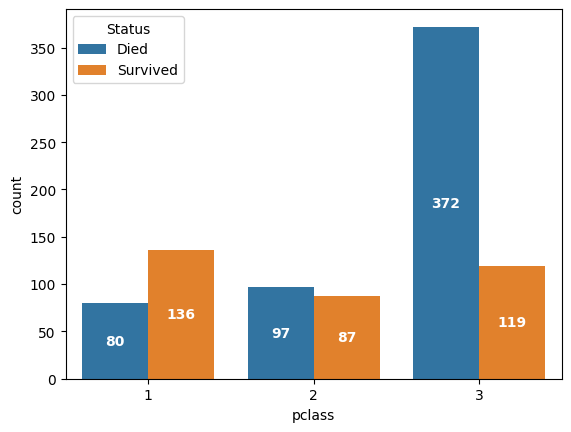

In [ ]:
# Survival by Passenger Class

ax=sns.countplot(x='pclass',
              hue='survived',
              data=df)
ax.legend(title='Status', labels=['Died', 'Survived'])
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

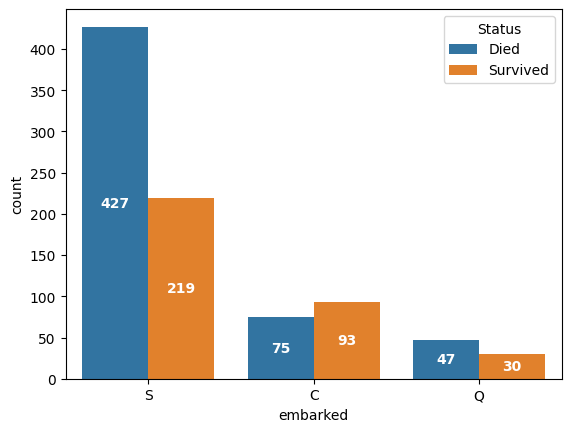

In [ ]:
# Survival by Embarked
ax=sns.countplot(x='embarked',
              hue='survived',
              data=df)
ax.legend(title='Status', labels=['Died', 'Survived'])
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', weight='bold')
plt.show()

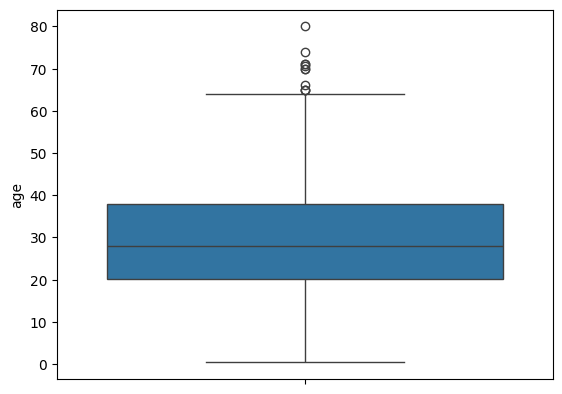

In [ ]:
# Age Boxplot

sns.boxplot(y='age', data=df)
plt.show()

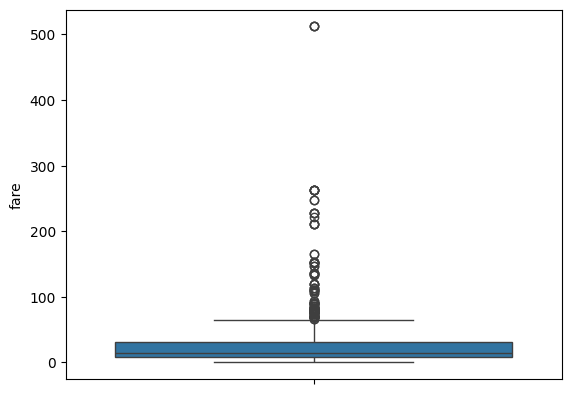

In [ ]:
# Fare Boxplot

sns.boxplot(y='fare', data=df)
plt.show()

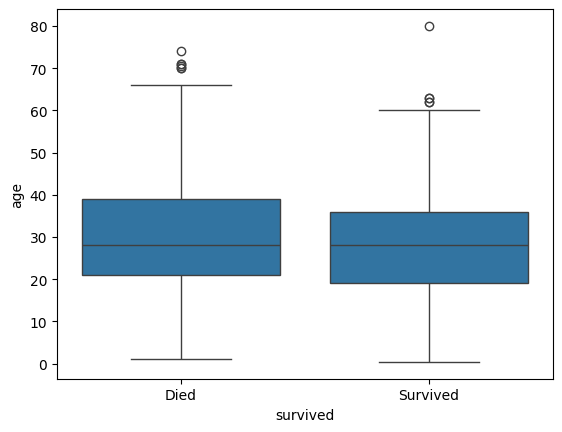

In [ ]:
# Age vs Survival

ax = sns.boxplot(x='survived',
            y='age',
            data=df)
ax.set_xticklabels(['Died', 'Survived'])
plt.show()

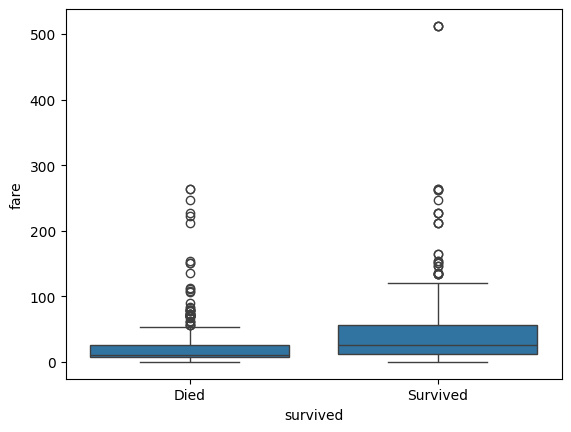

In [ ]:
# Fare vs Survival

ax= sns.boxplot(x='survived',
            y='fare',
            data=df)
ax.set_xticklabels(['Died', 'Survived'])
plt.show()

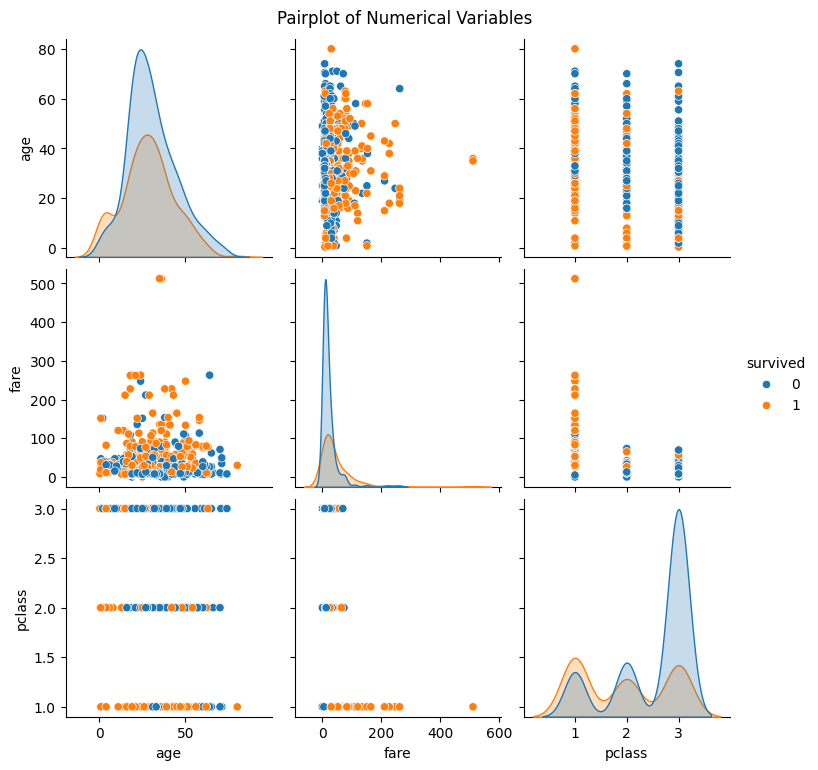

In [ ]:
# Pairplot

ax=sns.pairplot(df[['age',
                 'fare',
                 'pclass',
                 'survived']],
             hue='survived')
ax.fig.suptitle('Pairplot of Numerical Variables', y=1.02)
# ax.fig.subplots_adjust(top=0.9)
plt.show()

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df = pd.get_dummies(df, columns=['embarked'], drop_first=True, dtype=int)


In [ ]:
# 1. Fill missing numerical values first so they don't break the model
df['age'] = df['age'].fillna(df['age'].median())

# 2. Drop completely redundant columns to keep your dataset clean
# 'class' duplicates 'pclass', 'embark_town' duplicates 'embarked_Q/S', 'alive' duplicates 'survived'
columns_to_drop = ['class', 'who', 'adult_male', 'embark_town', 'alive', 'deck']
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Convert True/False columns into 1 and 0
df['alone'] = df['alone'].astype(int)

# 4. Convert 'sex' into 0 and 1 (male = 0, female = 1) and update the dataset
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)

# 5. Check your final, fully numeric dataset
df.shape
df


,survived,pclass,age,sibsp,parch,fare,alone,embarked_Q,embarked_S,sex_male
0,0,3,22.0,1,0,7.2500,0,0,1,1
1,1,1,38.0,1,0,71.2833,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,1,0
3,1,1,35.0,1,0,53.1000,0,0,1,0
4,0,3,35.0,0,0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,0,1,1
887,1,1,19.0,0,0,30.0000,1,0,1,0
888,0,3,28.0,1,2,23.4500,0,0,1,0
889,1,1,26.0,0,0,30.0000,1,0,0,1


In [ ]:
clean_df=df.copy()

In [ ]:
clean_df

,survived,pclass,age,sibsp,parch,fare,alone,embarked_Q,embarked_S,sex_male
0,0,3,22.0,1,0,7.2500,0,0,1,1
1,1,1,38.0,1,0,71.2833,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,1,0
3,1,1,35.0,1,0,53.1000,0,0,1,0
4,0,3,35.0,0,0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,0,1,1
887,1,1,19.0,0,0,30.0000,1,0,1,0
888,0,3,28.0,1,2,23.4500,0,0,1,0
889,1,1,26.0,0,0,30.0000,1,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split

# X contains all your independent features
X = clean_df.drop(columns=['survived'])

# y is your target variable (what we want to predict)
y = clean_df['survived']

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize and train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)


In [ ]:
print("--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred))
# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"Logistic Regression ROC-AUC Score: {roc_auc:.4f}")


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268

Logistic Regression ROC-AUC Score: 0.7935


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

# 2. Random Forest
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
forest_preds = forest_model.predict(X_test)

# 3. Compare Accuracies
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Decision Tree Accuracy:        {accuracy_score(y_test, tree_preds):.4f}")
print(f"Random Forest Accuracy:        {accuracy_score(y_test, forest_preds):.4f}")


Logistic Regression Accuracy: 0.8060
Decision Tree Accuracy:        0.7910
Random Forest Accuracy:        0.7873
